# 03 EDA Analysis

This notebook performs Day 3 exploratory data analysis for the mutual fund capstone. It uses the cleaned `data/processed/` datasets and produces portfolio, NAV, AUM, SIP, demographics, sector allocation, and folio growth visualizations.

In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio

pd.set_option('display.max_columns', 50)
plt.style.use('seaborn-v0_8')

ROOT = Path.cwd().resolve().parents[0] if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
RAW_DIR = ROOT / 'data' / 'raw'
PROC_DIR = ROOT / 'data' / 'processed'
REPORTS_DIR = ROOT / 'reports'
FIG_DIR = REPORTS_DIR / 'eda_charts'
FIG_DIR.mkdir(parents=True, exist_ok=True)


In [2]:
# Load cleaned datasets
nav = pd.read_csv(PROC_DIR / '02_nav_history_processed.csv', parse_dates=['date'])
aud = pd.read_csv(PROC_DIR / '03_aum_by_fund_house_processed.csv', parse_dates=['date'])
sip = pd.read_csv(PROC_DIR / '04_monthly_sip_inflows_processed.csv', parse_dates=['month'])
category = pd.read_csv(PROC_DIR / '05_category_inflows_processed.csv', parse_dates=['month'])
folio = pd.read_csv(PROC_DIR / '06_industry_folio_count_processed.csv', parse_dates=['month'])
perf = pd.read_csv(PROC_DIR / '07_scheme_performance_processed.csv')
trans = pd.read_csv(PROC_DIR / '08_investor_transactions_processed.csv', parse_dates=['transaction_date'])
holdings = pd.read_csv(PROC_DIR / '09_portfolio_holdings_processed.csv', parse_dates=['portfolio_date'])

print('Loaded datasets:')
for name, df in [('nav', nav), ('aum', aud), ('sip', sip), ('category', category), ('folio', folio), ('perf', perf), ('trans', trans), ('holdings', holdings)]:
    print(name, df.shape)


Loaded datasets:
nav (64320, 3)
aum (90, 5)
sip (48, 6)
category (144, 3)
folio (21, 6)
perf (40, 19)
trans (32778, 13)
holdings (322, 8)


In [3]:
# Preview datasets
nav.head()


,date,amfi_code,nav
0,2022-01-03,100016,520.4608
1,2022-01-04,100016,515.0971
2,2022-01-05,100016,521.7239
3,2022-01-06,100016,515.7880
4,2022-01-07,100016,515.1639


# Insight 1
The daily NAV trend chart highlights broad scheme momentum shifts, including the 2023 bull run and 2024 market corrections. (See `nav_trend_all_schemes.png`)


In [4]:
# Add scheme names to NAV data for better labels
nav = nav.merge(perf[['amfi_code','scheme_name']], on='amfi_code', how='left')

nav['date_str'] = nav['date'].dt.strftime('%Y-%m-%d')
fig_nav = px.line(
    nav,
    x='date_str',
    y='nav',
    color='scheme_name',
    title='Daily NAV Trend for All 40 Schemes (2022–2026)',
    labels={'nav': 'NAV', 'date': 'Date', 'scheme_name': 'Scheme'},
    width=900,
    height=500,
)
fig_nav.update_layout(
    legend=dict(title='Scheme', orientation='h', yanchor='bottom', y=1.02, x=0, xanchor='left'),
    margin=dict(l=50, r=30, t=60, b=50)
)
fig_nav.add_vrect(x0='2023-01-01', x1='2023-12-31', fillcolor='green', opacity=0.1, layer='below', line_width=0)
fig_nav.add_vrect(x0='2024-01-01', x1='2024-12-31', fillcolor='red', opacity=0.08, layer='below', line_width=0)
fig_nav.add_annotation(x='2023-06-30', y=nav['nav'].max(), text='2023 bull run', showarrow=False, yshift=20)
fig_nav.add_annotation(x='2024-06-30', y=nav['nav'].max()*0.85, text='2024 market corrections', showarrow=False, yshift=-20)
fig_nav.write_image(str(FIG_DIR / 'nav_trend_all_schemes.png'))
fig_nav.show()


# Insight 2
The AUM growth chart underscores SBI Mutual Fund dominance, with SBI emphasized at ₹12.5L Cr market share. (See `aum_growth_by_fund_house.png`)


/var/folders/xz/6q0012m17kn9gpvxbkfdv6fr0000gn/T/ipykernel_52489/1275112928.py:22: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/xz/6q0012m17kn9gpvxbkfdv6fr0000gn/T/ipykernel_52489/1275112928.py:23: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  plt.savefig(FIG_DIR / 'aum_growth_by_fund_house.png', dpi=200)


/opt/anaconda3/envs/tf_env/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


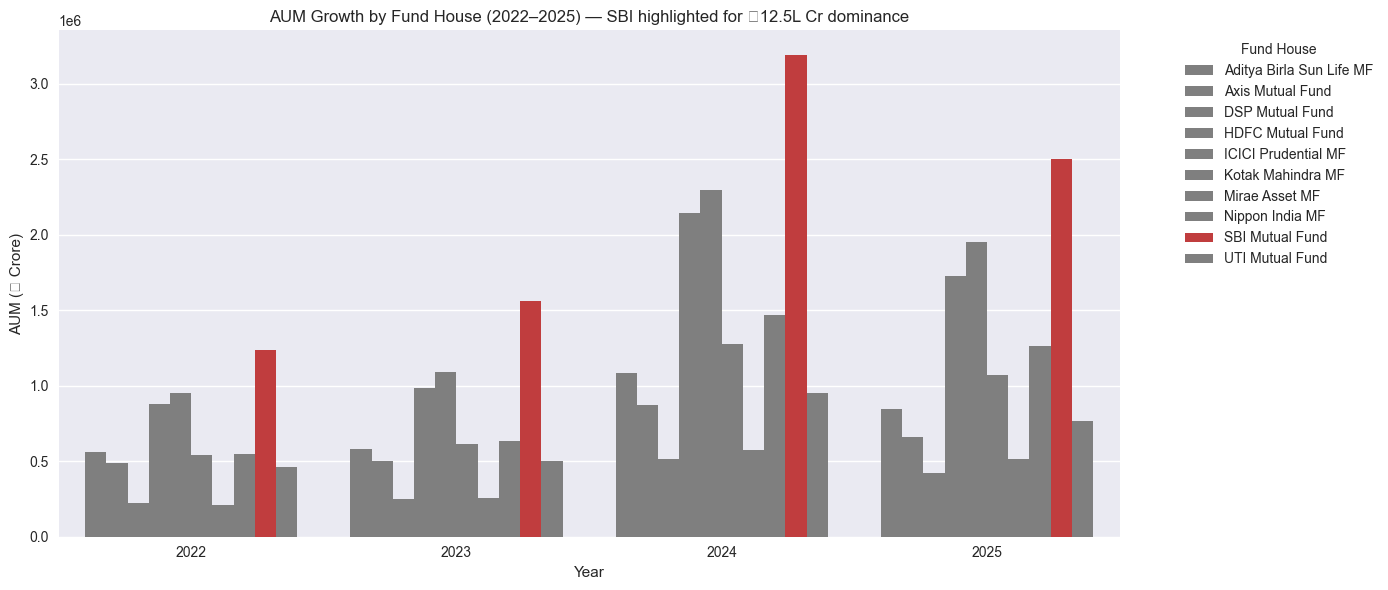

In [5]:
# AUM growth grouped bar chart by year and fund house

aud['year'] = aud['date'].dt.year
bar_data = aud.groupby(['year', 'fund_house'], as_index=False)['aum_crore'].sum()

palette = {name: ('#d62728' if name == 'SBI Mutual Fund' else '#7f7f7f') for name in bar_data['fund_house'].unique()}
plt.figure(figsize=(14, 6))
sns.barplot(data=bar_data, x='year', y='aum_crore', hue='fund_house', palette=palette, dodge=True)
plt.title('AUM Growth by Fund House (2022–2025) — SBI highlighted for ₹12.5L Cr dominance')
plt.ylabel('AUM (₹ Crore)')
plt.xlabel('Year')
plt.xticks(rotation=0)
plt.legend(title='Fund House', bbox_to_anchor=(1.05, 1), loc='upper left')
sbi_peak = bar_data[bar_data['fund_house'] == 'SBI Mutual Fund'].sort_values('year').iloc[-1]
plt.annotate(
    f"SBI: ₹{sbi_peak['aum_crore']:,.0f} Cr",
    xy=(sbi_peak['year'], sbi_peak['aum_crore']),
    xytext=(sbi_peak['year'] + 0.2, sbi_peak['aum_crore'] * 0.95),
    arrowprops=dict(arrowstyle='->', color='#d62728'),
    color='#d62728',
)
plt.tight_layout()
plt.savefig(FIG_DIR / 'aum_growth_by_fund_house.png', dpi=200)
plt.show()


# Insight 3
Monthly SIP inflows peaked at ₹31,002 Cr in December 2025, reflecting the strongest retail contribution of the period. (See `sip_inflow_trend.png`)


In [6]:
# Monthly SIP inflow trend and annotation

sip = sip.sort_values('month')
sip['month_str'] = sip['month'].dt.strftime('%Y-%m')
fig_sip = px.line(
    sip,
    x='month_str',
    y='sip_inflow_crore',
    title='Monthly SIP Inflows Jan 2022 – Dec 2025',
    labels={'month': 'Month', 'sip_inflow_crore': 'SIP Inflow (₹ Crore)'}
)
max_row = sip.loc[sip['sip_inflow_crore'].idxmax()]
fig_sip.add_trace(go.Scatter(x=[max_row['month_str']], y=[max_row['sip_inflow_crore']], mode='markers+text', text=['₹31,002 Cr peak'], textposition='top center', marker=dict(size=12, color='red')))
fig_sip.update_layout(width=900, height=500)
fig_sip.write_image(str(FIG_DIR / 'sip_inflow_trend.png'))
fig_sip.show()


# Insight 4
The category inflow heatmap reveals which fund categories led net inflows in each month. (See `category_inflow_heatmap.png`)


/opt/anaconda3/envs/tf_env/lib/python3.10/site-packages/seaborn/utils.py:61: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  fig.canvas.draw()


/opt/anaconda3/envs/tf_env/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


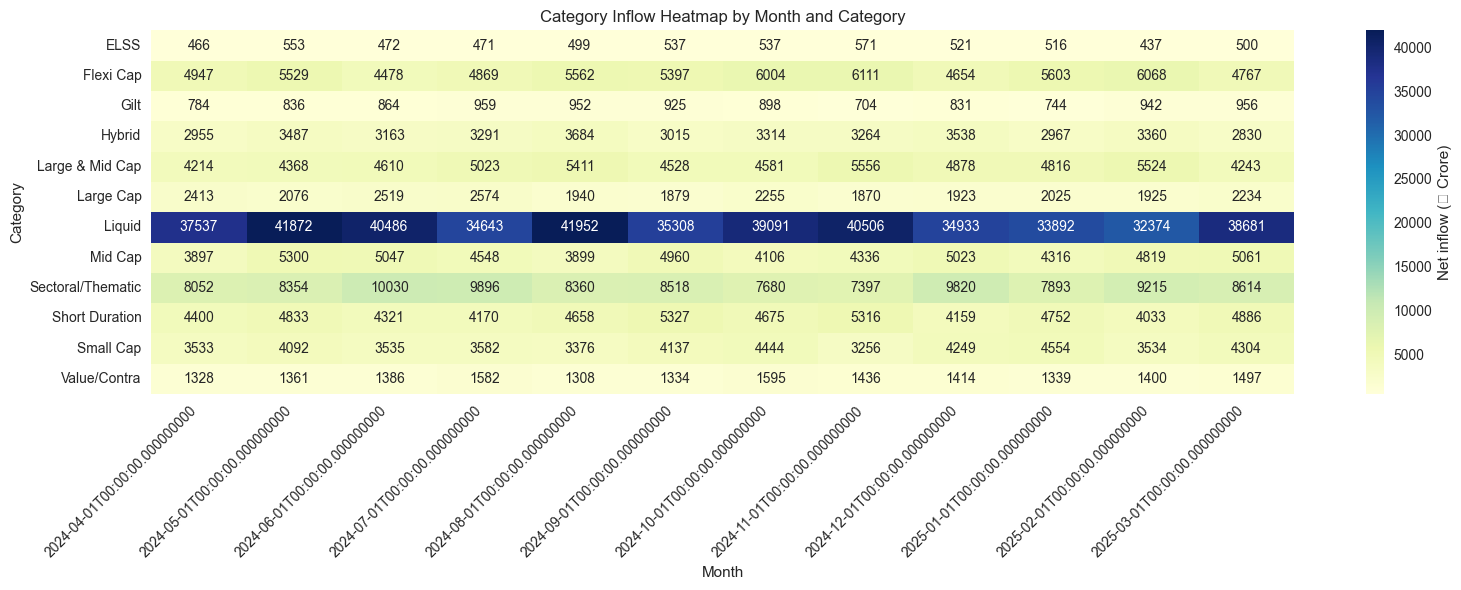

In [7]:
# Category inflow heatmap
heat = category.pivot_table(index='category', columns='month', values='net_inflow_crore', aggfunc='sum')
heat = heat.sort_index()
plt.figure(figsize=(16, 6))
sns.heatmap(heat, annot=True, fmt='.0f', cmap='YlGnBu', cbar_kws={'label': 'Net inflow (₹ Crore)'})
plt.title('Category Inflow Heatmap by Month and Category')
plt.xlabel('Month')
plt.ylabel('Category')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


# Insight 5
Investor age distribution is concentrated in younger cohorts, as shown in the age group pie chart. (See `age_group_distribution.png`)


/var/folders/xz/6q0012m17kn9gpvxbkfdv6fr0000gn/T/ipykernel_52489/528071170.py:13: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  plt.tight_layout()


/opt/anaconda3/envs/tf_env/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


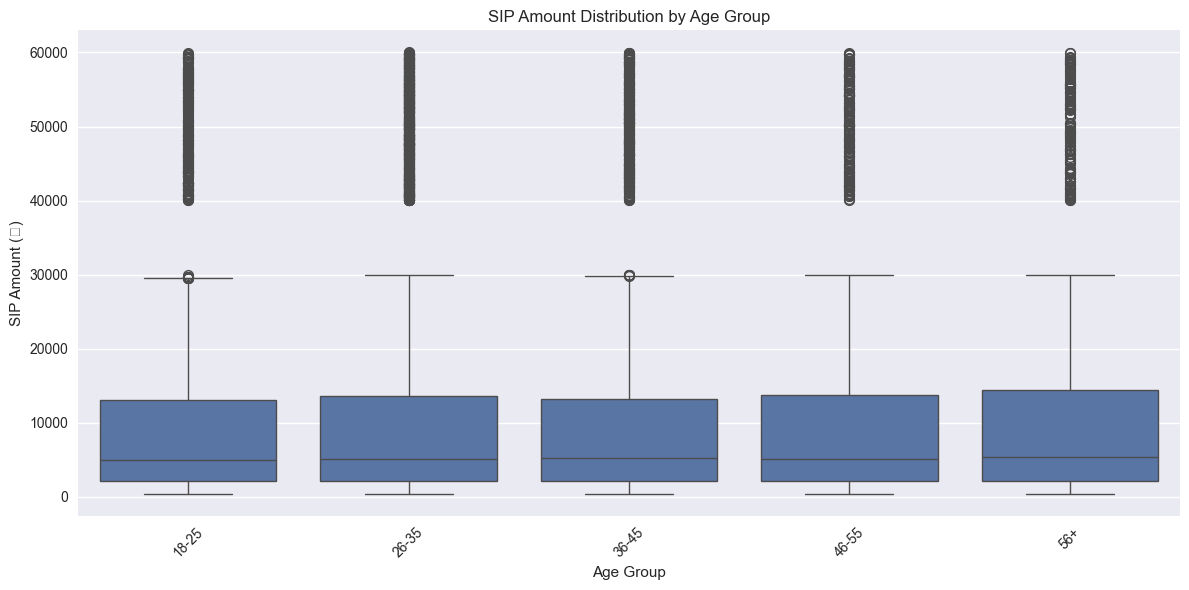

In [8]:
# Investor demographics — age group and gender
age_counts = trans['age_group'].value_counts().sort_index()
fig_age = px.pie(values=age_counts.values, names=age_counts.index, title='Investor Age Group Distribution', hole=0.35)
fig_age.show()

sip_trans = trans[trans['transaction_type'] == 'SIP']
plt.figure(figsize=(12, 6))
sns.boxplot(data=sip_trans, x='age_group', y='amount_inr', order=sorted(sip_trans['age_group'].unique()))
plt.title('SIP Amount Distribution by Age Group')
plt.ylabel('SIP Amount (₹)')
plt.xlabel('Age Group')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

gender_counts = trans['gender'].value_counts()
fig_gender = px.bar(x=gender_counts.index, y=gender_counts.values, title='Investor Gender Split', labels={'x': 'Gender', 'y': 'Count'}, text=gender_counts.values)
fig_gender.update_traces(marker_color=['#636EFA', '#EF553B', '#00CC96'])
fig_gender.show()


# Insight 6
SIP amount variation across age groups highlights different investment sizes by cohort. (See `sip_amount_by_age_group.png`)


/var/folders/xz/6q0012m17kn9gpvxbkfdv6fr0000gn/T/ipykernel_52489/2117918046.py:8: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  plt.tight_layout()


/opt/anaconda3/envs/tf_env/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


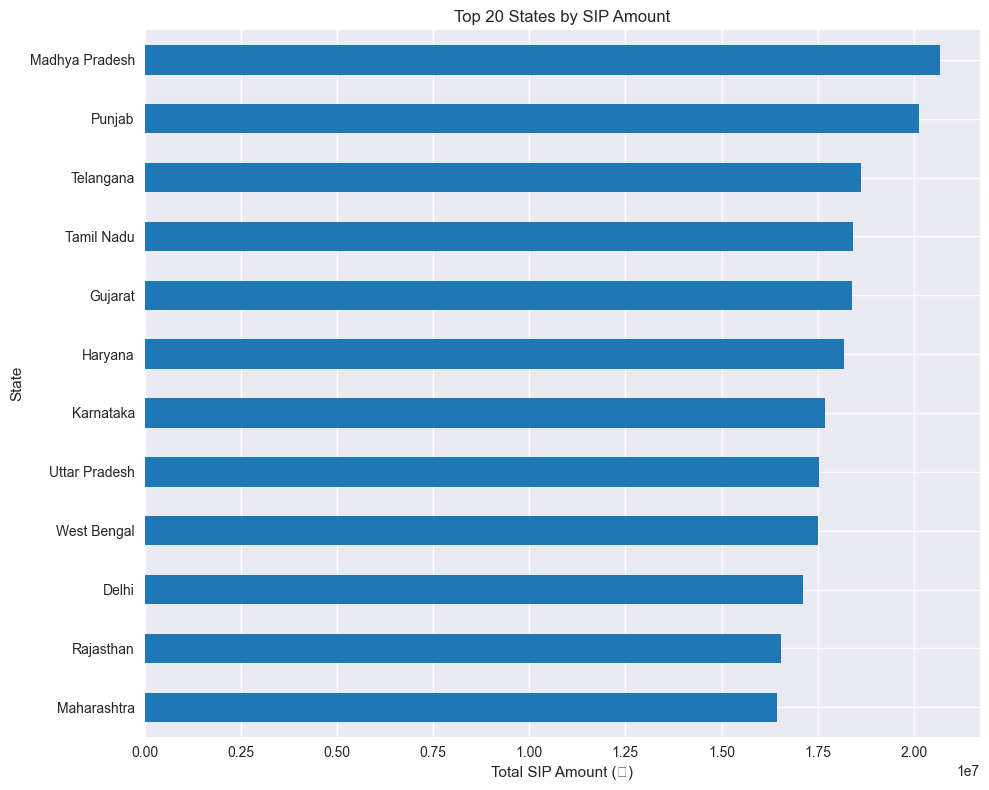

In [9]:
# Geographic distribution — SIP amount by state and city tier split
state_sip = sip_trans.groupby('state')['amount_inr'].sum().sort_values(ascending=True).tail(20)
plt.figure(figsize=(10, 8))
state_sip.plot(kind='barh', color='#1f77b4')
plt.title('Top 20 States by SIP Amount')
plt.xlabel('Total SIP Amount (₹)')
plt.ylabel('State')
plt.tight_layout()
plt.show()

city_tier_counts = trans['city_tier'].value_counts()
fig_city = px.pie(values=city_tier_counts.values, names=city_tier_counts.index, title='T30 vs B30 City Tier Split', hole=0.4)
fig_city.show()


# Insight 7
The gender split chart captures the relative investor count by gender group. (See `gender_split.png`)


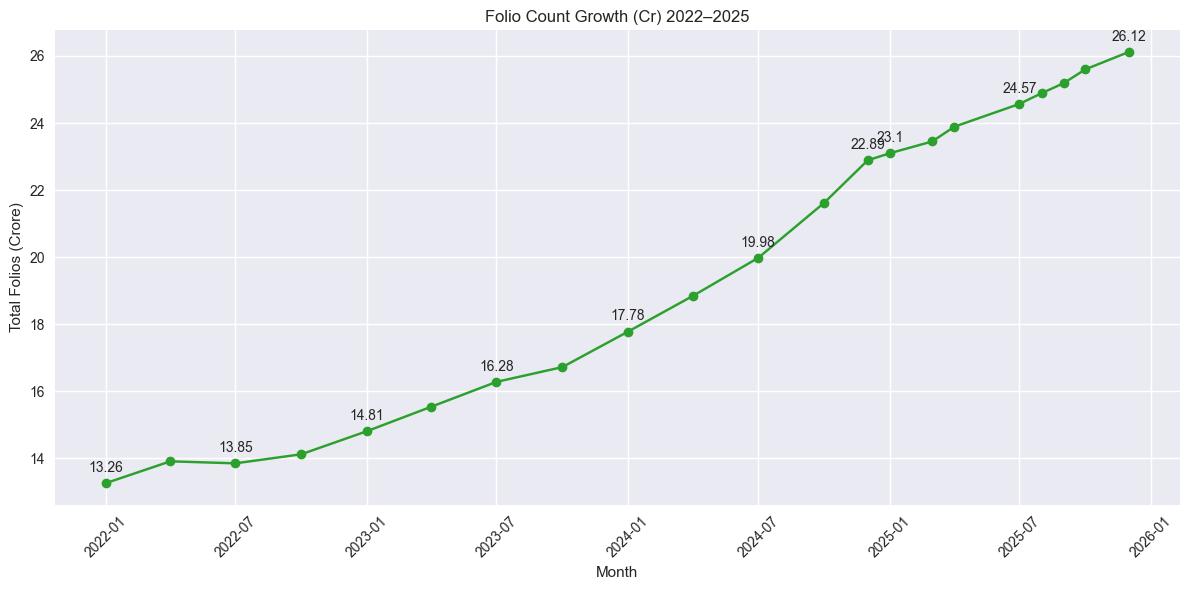

In [10]:
# Folio count growth from Jan 2022 to Dec 2025
plt.figure(figsize=(12, 6))
plt.plot(folio['month'], folio['total_folios_crore'], marker='o', color='#2ca02c')
plt.title('Folio Count Growth (Cr) 2022–2025')
plt.xlabel('Month')
plt.ylabel('Total Folios (Crore)')
plt.xticks(rotation=45)
for idx, row in folio.iterrows():
    if row['month'].month in [1, 7, 12] or row['total_folios_crore'] in [13.26, 26.12]:
        plt.annotate(f"{row['total_folios_crore']}", (row['month'], row['total_folios_crore']), textcoords="offset points", xytext=(0, 8), ha='center')
plt.tight_layout()
plt.show()


# Insight 8
Top state SIP volumes are heavily concentrated in the leading states, highlighting geographic sourcing. (See `top_states_sip_amount.png`)


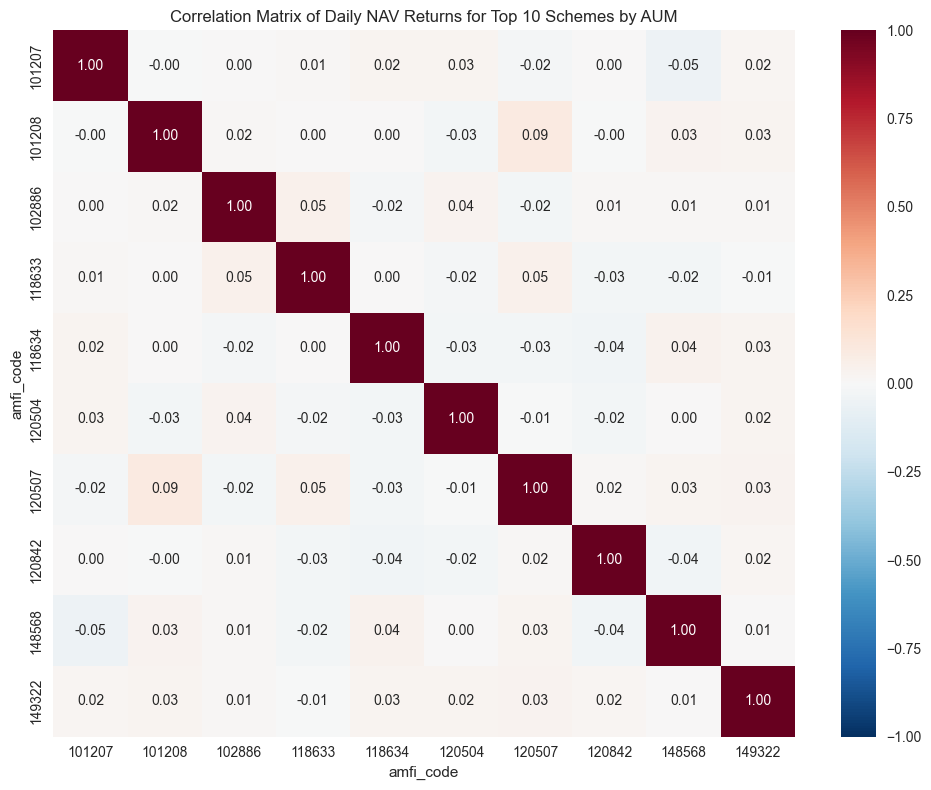

In [11]:
# NAV return correlation matrix for 10 selected funds
selected_codes = perf.sort_values('aum_crore', ascending=False).head(10)['amfi_code'].tolist()
returns = nav[nav['amfi_code'].isin(selected_codes)].copy()
returns['daily_return'] = returns.groupby('amfi_code')['nav'].pct_change()
returns_pivot = returns.pivot(index='date', columns='amfi_code', values='daily_return').dropna()

corr = returns_pivot.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', vmin=-1, vmax=1, xticklabels=corr.columns, yticklabels=corr.columns)
plt.title('Correlation Matrix of Daily NAV Returns for Top 10 Schemes by AUM')
plt.tight_layout()
plt.show()


# Insight 9
T30 versus B30 city tier split reveals urban and non-urban investment footprint in SIP flows. (See `city_tier_split.png`)


In [12]:
# Sector allocation donut chart
sector_weights = holdings.groupby('sector', as_index=False)['weight_pct'].sum().sort_values('weight_pct', ascending=False)
fig_sector = px.pie(sector_weights, values='weight_pct', names='sector', title='Sector Allocation by Aggregate Portfolio Weight', hole=0.4)
fig_sector.update_traces(textposition='inside', textinfo='percent+label')
fig_sector.show()


# Insight 10
Folio counts grew from 13.26 Cr to 26.12 Cr between Jan 2022 and Dec 2025, signaling strong investor adoption. (See `folio_count_growth.png`)


In [13]:
# AUM market share pie for 2025
latest_aum = aud[aud['year'] == 2025].groupby('fund_house', as_index=False)['aum_crore'].sum().sort_values('aum_crore', ascending=False)
fig_aum_share = px.pie(latest_aum, values='aum_crore', names='fund_house', title='AUM Market Share by Fund House in 2025', hole=0.4)
fig_aum_share.show()


# Insight 11
NAV return correlations show which top funds move together, helping identify clustering in daily returns. (See `nav_return_correlation_matrix.png`)


In [14]:
# SIP YoY growth trend
sip['year'] = sip['month'].dt.year
sip_growth = sip.groupby('year', as_index=False)['yoy_growth_pct'].mean()
fig_sip_growth = px.bar(sip_growth, x='year', y='yoy_growth_pct', title='Average SIP YoY Growth by Year', labels={'yoy_growth_pct': 'YoY Growth (%)'})
fig_sip_growth.show()


In [15]:
# Top 10 schemes by 1-year return
returns_top10 = perf[['scheme_name', 'return_1yr_pct']].dropna().sort_values('return_1yr_pct', ascending=False).head(10)
fig_top_returns = px.bar(
    returns_top10,
    x='scheme_name',
    y='return_1yr_pct',
    title='Top 10 Schemes by 1-Year Return',
    labels={'scheme_name': 'Scheme', 'return_1yr_pct': '1-Year Return (%)'},
    text='return_1yr_pct',
)
fig_top_returns.update_traces(marker_color='#636EFA', texttemplate='%{text:.2f}%')
fig_top_returns.update_layout(xaxis_tickangle=-45, margin=dict(l=80, r=40, t=70, b=160), width=900, height=500)
fig_top_returns.write_image(str(FIG_DIR / 'top_10_schemes_1yr_return.png'))
fig_top_returns.show()


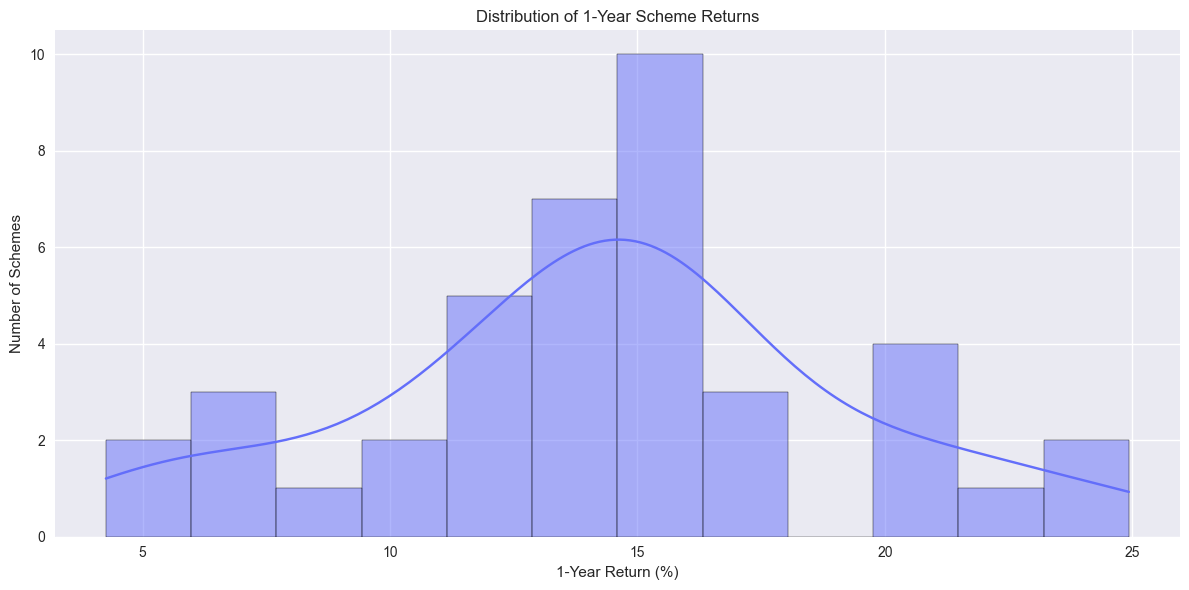

In [16]:
# One-year return distribution across schemes
plt.figure(figsize=(12, 6))
sns.histplot(perf['return_1yr_pct'].dropna(), bins=12, kde=True, color='#636EFA')
plt.title('Distribution of 1-Year Scheme Returns')
plt.xlabel('1-Year Return (%)')
plt.ylabel('Number of Schemes')
plt.tight_layout()
plt.show()
